In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from datetime import datetime, timedelta
from scipy.stats import beta

In [2]:
''' set file paths '''
root_dir = "Z:/Isabel/data/"
file = "surgeries_csv.csv"
save_dir = "../figures/methods/"

In [3]:
''' load and reformat the data '''
surgeries = {}
surgery_ids = []

# to reformat data
date_keys =['date', 'date caught', 'date upstairs']
time_keys = ['start time', 'end time']
num_keys = ['start weight', 'end weight', 'vol saline (mL)', 'N days survived']
bool_keys = ['survived surgery?', 'survived post-surgery?']

with open(f"{root_dir}{file}") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        if len(row['bird ID']) == 0:
            break
        bird_id = row['bird ID']
        
        # reformat data as needed
        for d in date_keys:
            date_str = row[d]
            date_obj = datetime.strptime(date_str, '%m/%d/%y').date()
            row[d] = date_obj
        date = row['date']
        
        for t in time_keys:
            time_str = row[t]
            time_obj = timedelta(hours=int(time_str[:2]), minutes=int(time_str[3:]))
            row[t] = time_obj
            
        for n in num_keys:
            num_str = row[n]
            num = float(num_str)
            row[n] = num
            
        for b in bool_keys:
            bool_str = row[b]
            if bool_str == 'Nan':
                bool_fixed = np.nan
            else:
                bool_fixed = bool(int(bool_str))
            row[b] = bool_fixed
        
        surgery_ids.append(f"{bird_id}_{date}")
        surgeries[f"{bird_id}_{date}"] = row
        print(f"{bird_id}, {date}")

CHC2, 2023-04-11
RBY23, 2023-04-12
RBY23, 2023-04-17
PRL113, 2023-04-25
SPP46, 2023-04-25
PRL113, 2023-05-15
SPP49, 2023-05-17
SLV146, 2023-05-17
SPP49, 2023-06-06
LIM87, 2023-06-13
SLV145, 2023-06-13
EMR67, 2023-06-22
ROS135, 2023-06-22
LIM87, 2023-06-27
SLV145, 2023-06-28
EMR67, 2023-07-13
ROS135, 2023-07-13
AMB5, 2023-07-17
EMR65, 2023-07-26
ROS135, 2023-07-27
PRL119, 2023-08-01
SPP152, 2023-08-07
EMR67, 2023-08-10
PRL119, 2023-08-23
CHC56, 2023-08-24
SPP152, 2023-08-28
SLV111, 2023-08-29
SPP47, 2023-08-29


In [37]:
''' basic surgery specs by surgery type '''
# type of surgery
total = 0
base_implants = 0
stim_implants = 0
probe_implants = 0

# duration of surgery
t_surgery = {
    'base': np.asarray([]),
    'stim': np.asarray([]),
    'probe': np.asarray([])
}

# weight added
w_added = {
    'base': np.asarray([]),
    'stim': np.asarray([]),
    'probe': np.asarray([])
}

# volume of saline given
v_saline = {
    'base': np.asarray([]),
    'stim': np.asarray([]),
    'probe': np.asarray([])
}

for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    
    # get specs
    t = int((surgery['end time'] - surgery['start time']).seconds / 60)
    w = surgery['end weight'] - surgery['start weight']
    vs = surgery['vol saline (mL)']

    # get type of surgery
    if 'stim' in surgery['procedure']:
        key = 'stim'
    elif 'base' in surgery['procedure']:
        key = 'base'
    elif 'probe' in surgery['procedure']:
        key = 'probe'
    else:
        continue
        
    # add to the appropriate field
    t_surgery[key] = np.append(t_surgery[key], t)
    w_added[key] = np.append(w_added[key], w)
    v_saline[key] = np.append(v_saline[key], vs)

In [50]:
for key in ['base', 'stim', 'probe']:
    t = t_surgery[key]
    w = w_added[key]
    vs = v_saline[key]
    
    w = w[~np.isnan(w)]   
    print(f'{key} implant specs:')
    print(f'duration: 5th pct = {np.round(np.percentile(t, 5))}, avg = {np.round(np.mean(t))}, 95th pct = {np.round(np.percentile(t, 95))}')
    print(f'weight added (g): 5th pct = {np.percentile(w, 5):.2}, avg = {np.mean(w):.2}, 95th pct = {np.percentile(w, 95):.2}')  
    print(f'saline (mL): 5th pct = {np.percentile(vs, 5):.4}, avg = {np.mean(vs):.4}, 95th pct = {np.percentile(t, 95):.4}\n')    

base implant specs:
duration: 5th pct = 60.0, avg = 80.0, 95th pct = 111.0
weight added (g): 5th pct = 0.84, avg = 1.1, 95th pct = 1.2
saline (mL): 5th pct = 0.49, avg = 0.66, 95th pct = 111.0

stim implant specs:
duration: 5th pct = 82.0, avg = 106.0, 95th pct = 127.0
weight added (g): 5th pct = 0.37, avg = 0.77, 95th pct = 1.0
saline (mL): 5th pct = 0.6, avg = 0.7333, 95th pct = 127.0

probe implant specs:
duration: 5th pct = 116.0, avg = 166.0, 95th pct = 227.0
weight added (g): 5th pct = 0.13, avg = 0.39, 95th pct = 0.84
saline (mL): 5th pct = 0.48, avg = 0.9778, 95th pct = 227.0



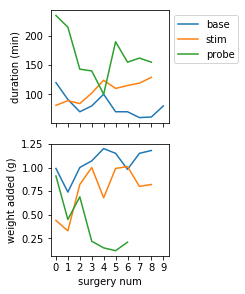

In [65]:
f, ax = plt.subplots(2, 1, figsize=(2.5, 4), sharex=True)
f.tight_layout()

for key in ['base', 'stim', 'probe']:
    ax[0].plot(t_surgery[key], label=key)
    w = w_added[key]
    w = w[~np.isnan(w)]
    ax[1].plot(w)
    
ax[0].set_ylabel('duration (min)')
ax[0].set_xticks(np.arange(t_surgery['base'].shape[0]))
ax[1].set_ylabel('weight added (g)')
ax[1].set_xlabel('surgery num')
ax[1].set_xticks(np.arange(t_surgery['base'].shape[0]))

ax[0].legend(bbox_to_anchor=(1, 1, 0, 0))
plt.show()

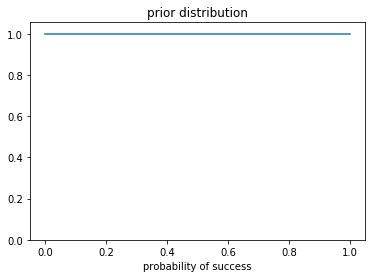

In [30]:
''' 
Beta binomial distribution
Estimate the true success rate using the observed survivals and deaths with a Bernoulli likelihood.
Assume a flat prior--all success rates are equally likely.
'''
## Prior Distribution
probs = np.linspace(0, 1, 100)
prior_a = 1 # pseudo success
prior_b = 1 # pseudo failure
prior = beta(prior_a, prior_b)
plt.plot(probs, prior.pdf(probs))
plt.ylim([0, plt.ylim()[1]])
plt.xlabel("probability of success")
plt.title("prior distribution")
plt.show()

IL: 5th pct = 0.451, mean = 0.602, 95th pct = 0.741
HP: 5th pct = 0.736, mean = 0.856, 95th pct = 0.936


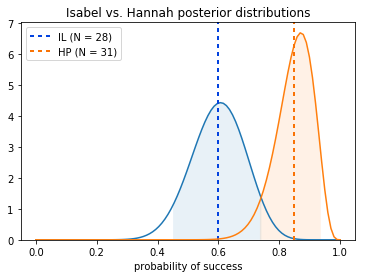

In [31]:
f = plt.figure()

# Isabel surgeries
num_successes = 17
num_failures = 11
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, 
            color='xkcd:blue', label='IL (N = 28)')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:blue')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:blue')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"IL: 5th pct = {posterior.ppf(.05):.3}, mean = {posterior.ppf(.5):.3}, 95th pct = {posterior.ppf(.95):.3}")

# Hannah surgeries
num_successes = 31 - 4
num_failures = 4
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, 
            color='xkcd:orange', label='HP (N = 31)')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:orange')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:orange')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"HP: 5th pct = {posterior.ppf(.05):.3}, mean = {posterior.ppf(.5):.3}, 95th pct = {posterior.ppf(.95):.3}")

plt.ylim([0, plt.ylim()[1]])
plt.xlabel("probability of success")
plt.title("Isabel vs. Hannah posterior distributions")

plt.legend(loc='upper left')
plt.show()
f.savefig(f'{save_dir}IL_vs_HP.png', dpi=600, bbox_inches='tight')

5th pct: 0.436, mean: 0.676, 95th pct: 0.865
5th pct: 0.368, mean: 0.552, 95th pct: 0.726


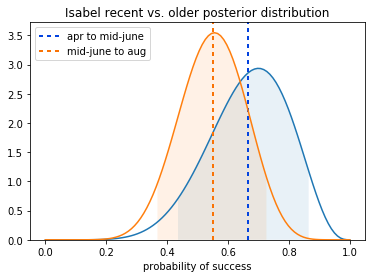

In [32]:
f = plt.figure()

# before mid-June
num_successes = 7
num_failures = 3
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, color='xkcd:blue', label='apr to mid-june')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:blue')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:blue')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"5th pct: {posterior.ppf(.05):.3}, mean: {posterior.ppf(.5):.3}, 95th pct: {posterior.ppf(.95):.3}")

# afer mid-June
num_successes = 10
num_failures = 8
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, color='xkcd:orange', label='mid-june to aug')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:orange')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:orange')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"5th pct: {posterior.ppf(.05):.3}, mean: {posterior.ppf(.5):.3}, 95th pct: {posterior.ppf(.95):.3}")

plt.ylim([0, plt.ylim()[1]])
plt.xlabel("probability of success")
plt.title("Isabel recent vs. older posterior distribution")

plt.legend(loc="upper left")
plt.show()
f.savefig(f'{save_dir}early_vs_late.png', dpi=600, bbox_inches='tight')

5th pct: 0.56, mean: 0.761, 95th pct: 0.903
5th pct: 0.244, mean: 0.435, 95th pct: 0.64


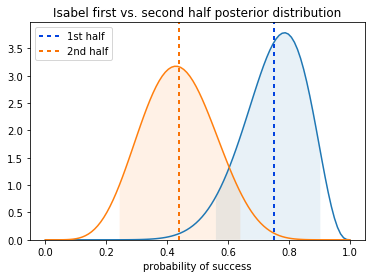

In [66]:
f = plt.figure()

# first half
num_successes = 11
num_failures = 3
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, color='xkcd:blue', label='1st half')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:blue')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:blue')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"5th pct: {posterior.ppf(.05):.3}, mean: {posterior.ppf(.5):.3}, 95th pct: {posterior.ppf(.95):.3}")

# second half
num_successes = 6
num_failures = 8
posterior = beta(prior_a + num_successes, prior_b + num_failures)
plt.plot(probs, posterior.pdf(probs))
plt.axvline(posterior.mean(), dashes=[2,2], lw=2, color='xkcd:orange', label='2nd half')
# plt.axvline(posterior.ppf(.05), dashes=[2,2], color='xkcd:orange')
# plt.axvline(posterior.ppf(.95), dashes=[2,2], color='xkcd:orange')
conf_int = np.linspace(posterior.ppf(.05), posterior.ppf(.95), 100)
plt.fill_between(
    conf_int, np.zeros(100), posterior.pdf(conf_int), alpha=0.1
)
print(f"5th pct: {posterior.ppf(.05):.3}, mean: {posterior.ppf(.5):.3}, 95th pct: {posterior.ppf(.95):.3}")

plt.ylim([0, plt.ylim()[1]])
plt.xlabel("probability of success")
plt.title("Isabel first vs. second half posterior distribution")

plt.legend(loc="upper left")
plt.show()
f.savefig(f'{save_dir}half_vs_half.png', dpi=600, bbox_inches='tight')

In [4]:
''' overall survival rate '''
total_surgeries = 0
survived = 0
for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    total_surgeries += 1
    if surgery['survived surgery?']:
        if surgery['survived post-surgery?']:
            survived += 1
print(f'overall survival rate = {survived/total_surgeries:.2%}')

overall survival rate = 60.71%


In [5]:
surgery_dates = []
for s in surgery_ids:
    date = surgeries[s]['date']
    surgery_dates.append(date)
start_date = surgery_dates[0]
halfway = (surgery_dates[-1] - surgery_dates[0]).days // 2

In [6]:
''' effect of experience - coarse '''
survived_early = 0
survived_late = 0
for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    date = surgery['date']
    if surgery['survived surgery?']:
        if surgery['survived post-surgery?']:
            if i < total_surgeries//2:
                survived_early += 1
            else:
                survived_late += 1
print("divided by n surgeries performed:")
print(f"early survival rate = {survived_early}/{total_surgeries//2} or {survived_early/(total_surgeries//2):.2%}")
print(f"late survival rate = {survived_late}/{total_surgeries//2} or {survived_late/(total_surgeries//2):.2%}")

divided by n surgeries performed:
early survival rate = 11/14 or 78.57%
late survival rate = 6/14 or 42.86%


In [7]:
''' effect of time '''
n_per_half = np.zeros(2)
survived_by_date = np.zeros(2)
for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    date = surgery['date']
    if (date - start_date).days < halfway:
        n_per_half[0] += 1
    else:
        n_per_half[1] += 1
    if surgery['survived surgery?']:
        if surgery['survived post-surgery?']:
            if (date - start_date).days < halfway:
                survived_by_date[0] +=1
            else:
                survived_by_date[1] +=1
print(f"divided by halfway point in time:")
print(f"early survival rate = {survived_by_date[0]}/{n_per_half[0]} or {survived_by_date[0]/n_per_half[0]:.2%}")
print(f"late survival rate = {survived_by_date[1]}/{n_per_half[1]} or {survived_by_date[1]/n_per_half[1]:.2%}")

divided by halfway point in time:
early survival rate = 8.0/11.0 or 72.73%
late survival rate = 9.0/17.0 or 52.94%


In [8]:
''' deaths overall '''
total = np.zeros(3) # during, after, total

# type of surgery
base_implants = np.zeros(3) # during, after, total
stim_implants = np.zeros(3)
probe_implants = np.zeros(3)

# duration of surgery
t_surgery_died = np.asarray([])
t_surgery_survived = np.asarray([])

# weight added
w_added_died = np.asarray([])
w_added_survived = np.asarray([])

# volume of saline given
saline_died = np.asarray([])
saline_survived = np.asarray([])

# days since capture/brought to the satellite
d_captivity_died = np.asarray([])
d_captivity_survived = np.asarray([])
d_upstairs_died = np.asarray([])
d_upstairs_survived = np.asarray([])

for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    total[-1] += 1
    if surgery["survived surgery?"]:
        lived = surgery["survived post-surgery?"]
        idx = 1
    else:
        lived = False
        idx = 0

    # type of surgery
    if 'base' in surgery['procedure']:
        base_implants[-1] += 1
        base = True
    else:
        base = False
    if 'stim' in surgery['procedure']:
        stim_implants[-1] += 1
        stim = True
    else:
        stim = False
    if 'probe' in surgery['procedure']:
        probe_implants[-1] += 1
        probe = True
    else:
        probe = False

    # compute durations, weight change, etc.
    t_surgery = int((surgery['end time'] - surgery['start time']).seconds / 60)
    w_added = surgery['end weight'] - surgery['start weight']
    d_captivity = (surgery['date'] - surgery['date caught']).days
    d_upstairs = (surgery['date'] - surgery['date upstairs']).days

    if lived:
        t_surgery_survived = np.append(t_surgery_survived, t_surgery)
        w_added_survived = np.append(w_added_survived, w_added)
        d_captivity_survived = np.append(d_captivity_survived, d_captivity)
        d_upstairs_survived = np.append(d_upstairs_survived, d_upstairs)
        saline_survived = np.append(saline_survived, surgery['vol saline (mL)'])
    else:
        total[idx] += 1
        t_surgery_died = np.append(t_surgery_died, t_surgery)
        w_added_died = np.append(w_added_died, w_added)
        d_captivity_died = np.append(d_captivity_died, d_captivity)
        d_upstairs_died = np.append(d_upstairs_died, d_upstairs)
        saline_died = np.append(saline_died, surgery['vol saline (mL)'])
        if base:
            base_implants[idx] += 1
        if stim:
            stim_implants[idx] += 1
        if probe:
            probe_implants[idx] += 1

In [9]:
# organize all the data
total = total.astype(int)
base_implants = base_implants.astype(int)
stim_implants = stim_implants.astype(int)
probe_implants = probe_implants.astype(int)

base_deaths = base_implants[0] + base_implants[1]
stim_deaths = stim_implants[0] + stim_implants[1]
probe_deaths = probe_implants[0] + probe_implants[1]
total_deaths = total[0] + total[1]

died_factors = [t_surgery_died, w_added_died, saline_died, d_captivity_died, d_upstairs_died]
survived_factors = [t_surgery_survived, w_added_survived, saline_survived, d_captivity_survived, d_upstairs_survived]

In [10]:
print(f"{total[-1]-total_deaths} out of {total[-1]} surgeries survived")
print(f"Of the {total_deaths} deaths:")
print(f"{base_deaths} were base implants, {stim_deaths} were stim implants, and {probe_deaths} were probe implants")
print(f"{base_deaths}/{base_implants[-1]} base implanted birds died ({base_deaths/base_implants[-1]:.2%})")
print(f"{stim_deaths}/{stim_implants[-1]} stim implanted birds died ({stim_deaths/stim_implants[-1]:.2%})")
print(f"{probe_deaths}/{probe_implants[-1]} probe implanted birds died ({probe_deaths/probe_implants[-1]:.2%})")

17 out of 28 surgeries survived
Of the 11 deaths:
6 were base implants, 3 were stim implants, and 5 were probe implants
6/17 base implanted birds died (35.29%)
3/9 stim implanted birds died (33.33%)
5/9 probe implanted birds died (55.56%)


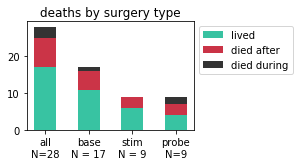

In [11]:
''' proportion of deaths overall and by surgery type'''
# data params
counts = []
for i in np.asarray([2, 1, 0]):
    counts.append(np.asarray([total[i], base_implants[i], stim_implants[i], probe_implants[i]]))
counts[0] = counts[0] - np.asarray([total_deaths, base_deaths, stim_deaths, probe_deaths])
    
# fig params
f, ax = plt.subplots(1, 1, figsize=(3, 2))
bottoms = np.zeros(4)
width = 0.5
category = ['lived', 'died after', 'died during']
conditions = ['all\nN=28', 'base\nN = 17', 'stim\nN = 9', 'probe\nN=9']
colors = ['xkcd:green blue', 'xkcd:scarlet', 'k']

for i, ct in enumerate(counts):
    ax.bar(conditions, ct, width=width, 
           label=category[i], bottom=bottoms, 
           color=colors[i], alpha=0.8)
    bottoms += ct
    
ax.set_title('deaths by surgery type', fontsize=12, pad=5)
ax.legend(bbox_to_anchor=(1, 1, 0, 0))
plt.show()
f.savefig(f'{save_dir}surgery_type.png', dpi=600, bbox_inches='tight')

C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\core\_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\linalg\linalg.py:2159: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


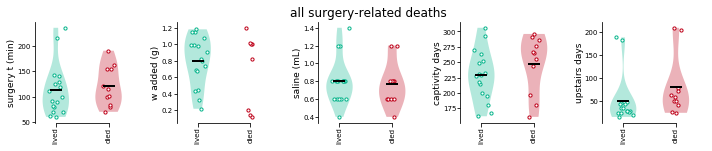

In [182]:
''' deaths overall - plot some factors '''
# fig params 
f, ax = plt.subplots(1, len(survived_factors), figsize=(len(survived_factors)*2, 2))
f.tight_layout()
DOT_LW = 1
DOT_SIZE = 10
AVG_LW = 2

lived_color = 'xkcd:green blue'
died_color = 'xkcd:scarlet'
labels = ['surgery t (min)', 'w added (g)', 'saline (mL)', 'captivity days', 'upstairs days']

n_survived = t_surgery_survived.shape[0]
JIT_LIVED = np.random.randn(n_survived) * 0.06 # jitter points
n_died = t_surgery_died.shape[0]
JIT_DIED = np.random.randn(n_died) * 0.06 # jitter points

for i, (died, lived) in enumerate(zip(died_factors, survived_factors)):
    V = ax[i].violinplot([lived, died], showextrema=False)
    for j, v in enumerate(V['bodies']):
        v.set_facecolor(colors[j])
    ax[i].scatter(np.full(n_survived, 1) + JIT_LIVED,
                  lived,
                  facecolors='w', edgecolors=lived_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].scatter(np.full(n_died, 2) + JIT_DIED,
                  died,
                  facecolors='w', edgecolors=died_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].plot(np.asarray([1, 2]),
               np.asarray([np.mean(lived), np.mean(died)]),
               '_k', ms=12, mew=2
              )
    
for i in range(len(survived_factors)):
    # ticks and lims
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
#     ax[i].spines['left'].set_bounds(0, 1)
    ax[i].spines['bottom'].set_bounds(1, 2)
    ax[i].set_xlim([0.6, 2.5])
    ax[i].set_xticks([1, 2])

    # labels
    ax[i].set_ylabel(labels[i], fontsize=9, labelpad=1)
    ax[i].set_xticklabels(['lived', 'died'], rotation=90)
    ax[i].tick_params(which='major', labelsize=7, pad=0.5)
    
    if i == 2:
        ax[i].set_title('all surgery-related deaths', fontsize=12, pad=5)

f.savefig(f'{save_dir}surgery_deaths.png', dpi=600, bbox_inches='tight')

In [166]:
''' deaths after surgery '''
total = 0
total_survived = 0

# type of surgery
base_implants = np.zeros(2)
stim_implants = np.zeros(2)
probe_implants = np.zeros(2)

# duration of surgery
t_surgery_died = np.asarray([])
t_surgery_survived = np.asarray([])

# weight added
w_added_died = np.asarray([])
w_added_survived = np.asarray([])

# volume of saline given
saline_died = np.asarray([])
saline_survived = np.asarray([])

# days since capture/brought to the satellite
d_captivity_died = np.asarray([])
d_captivity_survived = np.asarray([])
d_upstairs_died = np.asarray([])
d_upstairs_survived = np.asarray([])

for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    if surgery["survived surgery?"]:
        total += 1
        lived = surgery["survived post-surgery?"]
        total_survived += int(lived)
        
        # type of surgery
        if 'base' in surgery['procedure']:
            base_implants[1] += 1
            base = True
        else:
            base = False
        if 'stim' in surgery['procedure']:
            stim_implants[1] += 1
            stim = True
        else:
            stim = False
        if 'probe' in surgery['procedure']:
            probe_implants[1] += 1
            probe = True
        else:
            probe = False
        
        # compute durations, weight change, etc.
        t_surgery = int((surgery['end time'] - surgery['start time']).seconds / 60)
        w_added = surgery['end weight'] - surgery['start weight']
        d_captivity = (surgery['date'] - surgery['date caught']).days
        d_upstairs = (surgery['date'] - surgery['date upstairs']).days
        
        if lived:
            t_surgery_survived = np.append(t_surgery_survived, t_surgery)
            w_added_survived = np.append(w_added_survived, w_added)
            d_captivity_survived = np.append(d_captivity_survived, d_captivity)
            d_upstairs_survived = np.append(d_upstairs_survived, d_upstairs)
            saline_survived = np.append(saline_survived, surgery['vol saline (mL)'])
        else:
            t_surgery_died = np.append(t_surgery_died, t_surgery)
            w_added_died = np.append(w_added_died, w_added)
            d_captivity_died = np.append(d_captivity_died, d_captivity)
            d_upstairs_died = np.append(d_upstairs_died, d_upstairs)
            saline_died = np.append(saline_died, surgery['vol saline (mL)'])
            if base:
                base_implants[0] += 1
            if stim:
                stim_implants[0] += 1
            if probe:
                probe_implants[0] += 1

In [167]:
# organize all the data
base_implants = base_implants.astype(int)
stim_implants = stim_implants.astype(int)
probe_implants = probe_implants.astype(int)

died_factors = [t_surgery_died, w_added_died, saline_died, d_captivity_died, d_upstairs_died]
survived_factors = [t_surgery_survived, w_added_survived, saline_survived, d_captivity_survived, d_upstairs_survived]

In [168]:
print(f"{total_survived} out of {total} surgeries survived")
print(f"Of the {total - total_survived} deaths following surgery:")
print(f"{base_implants[0]} were base implants, {stim_implants[0]} were stim implants, and {probe_implants[0]} were probe implants")
print(f"{base_implants[0]}/{base_implants[1]} base implanted birds died following surgery ({base_implants[0]/base_implants[1]:.2%})")
print(f"{stim_implants[0]}/{stim_implants[1]} stim implanted birds died following surgery ({stim_implants[0]/stim_implants[1]:.2%})")
print(f"{probe_implants[0]}/{probe_implants[1]} probe implanted birds died following surgery ({probe_implants[0]/probe_implants[1]:.2%})")

Of the 8 deaths following surgery:
5 were base implants, 3 were stim implants, and 3 were probe implants
5/16 base implanted birds died following surgery (31.25%)
3/9 stim implanted birds died following surgery (33.33%)
3/7 probe implanted birds died following surgery (42.86%)


C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\core\_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


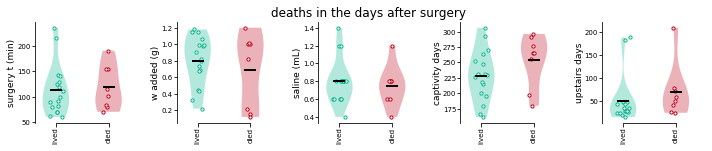

In [178]:
''' death following surgery - plot some factors '''
# fig params 
f, ax = plt.subplots(1, len(survived_factors), figsize=(len(survived_factors)*2, 2))
f.tight_layout()
DOT_LW = 1
DOT_SIZE = 10
AVG_LW = 2

lived_color = 'xkcd:green blue'
died_color = 'xkcd:scarlet'
colors = [lived_color, died_color]
labels = ['surgery t (min)', 'w added (g)', 'saline (mL)', 'captivity days', 'upstairs days']

n_survived = t_surgery_survived.shape[0]
JIT_LIVED = np.random.randn(n_survived) * 0.06 # jitter points
n_died = t_surgery_died.shape[0]
JIT_DIED = np.random.randn(n_died) * 0.06 # jitter points

for i, (died, lived) in enumerate(zip(died_factors, survived_factors)):
    V = ax[i].violinplot([lived, died], showextrema=False)
    for j, v in enumerate(V['bodies']):
        v.set_facecolor(colors[j])
    ax[i].scatter(np.full(n_survived, 1) + JIT_LIVED,
                  lived,
                  facecolors='w', edgecolors=lived_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].scatter(np.full(n_died, 2) + JIT_DIED,
                  died,
                  facecolors='w', edgecolors=died_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].plot(np.asarray([1, 2]),
               np.asarray([np.mean(lived), np.mean(died)]),
               '_k', ms=12, mew=2
              )
    
for i in range(len(survived_factors)):
    # ticks and lims
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
#     ax[i].spines['left'].set_bounds(0, 1)
    ax[i].spines['bottom'].set_bounds(1, 2)
    ax[i].set_xlim([0.6, 2.5])
    ax[i].set_xticks([1, 2])

    # labels
    ax[i].set_ylabel(labels[i], fontsize=9, labelpad=1)
    ax[i].set_xticklabels(['lived', 'died'], rotation=90)
    ax[i].tick_params(which='major', labelsize=7, pad=0.5)
    
    if i == 2:
        ax[i].set_title('deaths in the days after surgery', fontsize=12, pad=5)

f.savefig(f'{save_dir}deaths_after_surgery.png', dpi=600, bbox_inches='tight')

In [195]:
''' deaths in more recent surgeries '''
total = 0
total_survived = 0

# type of surgery
base_implants = np.zeros(2)
stim_implants = np.zeros(2)
probe_implants = np.zeros(2)

# duration of surgery
t_surgery_died = np.asarray([])
t_surgery_survived = np.asarray([])

# weight added
w_added_died = np.asarray([])
w_added_survived = np.asarray([])

# volume of saline given
saline_died = np.asarray([])
saline_survived = np.asarray([])

# days since capture/brought to the satellite
d_captivity_died = np.asarray([])
d_captivity_survived = np.asarray([])
d_upstairs_died = np.asarray([])
d_upstairs_survived = np.asarray([])

for i, s in enumerate(surgery_ids[10:]):
    surgery = surgeries[s]
    total += 1
    if surgery["survived surgery?"]:
        lived = surgery["survived post-surgery?"]
        total_survived += int(lived)    
    else:
        lived = False

    # type of surgery
    if 'base' in surgery['procedure']:
        base_implants[1] += 1
        base = True
    else:
        base = False
    if 'stim' in surgery['procedure']:
        stim_implants[1] += 1
        stim = True
    else:
        stim = False
    if 'probe' in surgery['procedure']:
        probe_implants[1] += 1
        probe = True
    else:
        probe = False

    # compute durations, weight change, etc.
    t_surgery = int((surgery['end time'] - surgery['start time']).seconds / 60)
    w_added = surgery['end weight'] - surgery['start weight']
    d_captivity = (surgery['date'] - surgery['date caught']).days
    d_upstairs = (surgery['date'] - surgery['date upstairs']).days

    if lived:
        t_surgery_survived = np.append(t_surgery_survived, t_surgery)
        w_added_survived = np.append(w_added_survived, w_added)
        d_captivity_survived = np.append(d_captivity_survived, d_captivity)
        d_upstairs_survived = np.append(d_upstairs_survived, d_upstairs)
        saline_survived = np.append(saline_survived, surgery['vol saline (mL)'])
    else:
        t_surgery_died = np.append(t_surgery_died, t_surgery)
        w_added_died = np.append(w_added_died, w_added)
        d_captivity_died = np.append(d_captivity_died, d_captivity)
        d_upstairs_died = np.append(d_upstairs_died, d_upstairs)
        saline_died = np.append(saline_died, surgery['vol saline (mL)'])
        if base:
            base_implants[0] += 1
        if stim:
            stim_implants[0] += 1
        if probe:
            probe_implants[0] += 1

In [196]:
# organize all the data
base_implants = base_implants.astype(int)
stim_implants = stim_implants.astype(int)
probe_implants = probe_implants.astype(int)

died_factors = [t_surgery_died, w_added_died, saline_died, d_captivity_died, d_upstairs_died]
survived_factors = [t_surgery_survived, w_added_survived, saline_survived, d_captivity_survived, d_upstairs_survived]

In [197]:
print(f"{total_survived} out of {total} surgeries survived")
print(f"Of the {total - total_survived} deaths:")
print(f"{base_implants[0]} were base implants, {stim_implants[0]} were stim implants, and {probe_implants[0]} were probe implants")
print(f"{base_implants[0]}/{base_implants[1]} base implanted birds died ({base_implants[0]/base_implants[1]:.2%})")
print(f"{stim_implants[0]}/{stim_implants[1]} stim implanted birds died ({stim_implants[0]/stim_implants[1]:.2%})")
print(f"{probe_implants[0]}/{probe_implants[1]} probe implanted birds died ({probe_implants[0]/probe_implants[1]:.2%})")

10 out of 18 surgeries survived
Of the 8 deaths:
3 were base implants, 3 were stim implants, and 5 were probe implants
3/10 base implanted birds died (30.00%)
3/9 stim implanted birds died (33.33%)
5/6 probe implanted birds died (83.33%)


C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\core\_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\linalg\linalg.py:2159: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


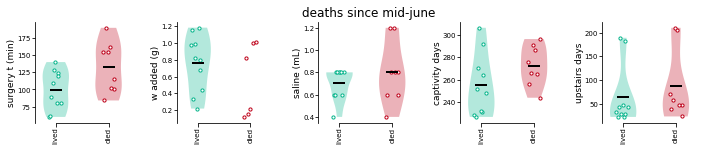

In [198]:
''' more recent deaths - plot some factors '''
# fig params 
f, ax = plt.subplots(1, len(survived_factors), figsize=(len(survived_factors)*2, 2))
f.tight_layout()
DOT_LW = 1
DOT_SIZE = 10
AVG_LW = 2

lived_color = 'xkcd:green blue'
died_color = 'xkcd:scarlet'
labels = ['surgery t (min)', 'w added (g)', 'saline (mL)', 'captivity days', 'upstairs days']

n_survived = t_surgery_survived.shape[0]
JIT_LIVED = np.random.randn(n_survived) * 0.06 # jitter points
n_died = t_surgery_died.shape[0]
JIT_DIED = np.random.randn(n_died) * 0.06 # jitter points

for i, (died, lived) in enumerate(zip(died_factors, survived_factors)):
    V = ax[i].violinplot([lived, died], showextrema=False)
    for j, v in enumerate(V['bodies']):
        v.set_facecolor(colors[j])
    ax[i].scatter(np.full(n_survived, 1) + JIT_LIVED,
                  lived,
                  facecolors='w', edgecolors=lived_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].scatter(np.full(n_died, 2) + JIT_DIED,
                  died,
                  facecolors='w', edgecolors=died_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].plot(np.asarray([1, 2]),
               np.asarray([np.mean(lived), np.mean(died)]),
               '_k', ms=12, mew=2
              )
    
for i in range(len(survived_factors)):
    # ticks and lims
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
#     ax[i].spines['left'].set_bounds(0, 1)
    ax[i].spines['bottom'].set_bounds(1, 2)
    ax[i].set_xlim([0.6, 2.5])
    ax[i].set_xticks([1, 2])

    # labels
    ax[i].set_ylabel(labels[i], fontsize=9, labelpad=1)
    ax[i].set_xticklabels(['lived', 'died'], rotation=90)
    ax[i].tick_params(which='major', labelsize=7, pad=0.5)
    
    if i == 2:
        ax[i].set_title('deaths since mid-june', fontsize=12, pad=5)

f.savefig(f'{save_dir}recent_surgery_deaths.png', dpi=600, bbox_inches='tight')

In [4]:
''' recent deaths '''
total = np.zeros(3) # during, after, total

# type of surgery
base_implants = np.zeros(3) # during, after, total
stim_implants = np.zeros(3)
probe_implants = np.zeros(3)

# duration of surgery
t_surgery_died = np.asarray([])
t_surgery_survived = np.asarray([])

# weight added
w_added_died = np.asarray([])
w_added_survived = np.asarray([])

# volume of saline given
saline_died = np.asarray([])
saline_survived = np.asarray([])

# days since capture/brought to the satellite
d_captivity_died = np.asarray([])
d_captivity_survived = np.asarray([])
d_upstairs_died = np.asarray([])
d_upstairs_survived = np.asarray([])

for i, s in enumerate(surgery_ids[10:]):
    surgery = surgeries[s]
    total[-1] += 1
    if surgery["survived surgery?"]:
        lived = surgery["survived post-surgery?"]
        idx = 1
    else:
        lived = False
        idx = 0

    # type of surgery
    if 'base' in surgery['procedure']:
        base_implants[-1] += 1
        base = True
    else:
        base = False
    if 'stim' in surgery['procedure']:
        stim_implants[-1] += 1
        stim = True
    else:
        stim = False
    if 'probe' in surgery['procedure']:
        probe_implants[-1] += 1
        probe = True
    else:
        probe = False

    # compute durations, weight change, etc.
    t_surgery = int((surgery['end time'] - surgery['start time']).seconds / 60)
    w_added = surgery['end weight'] - surgery['start weight']
    d_captivity = (surgery['date'] - surgery['date caught']).days
    d_upstairs = (surgery['date'] - surgery['date upstairs']).days

    if lived:
        t_surgery_survived = np.append(t_surgery_survived, t_surgery)
        w_added_survived = np.append(w_added_survived, w_added)
        d_captivity_survived = np.append(d_captivity_survived, d_captivity)
        d_upstairs_survived = np.append(d_upstairs_survived, d_upstairs)
        saline_survived = np.append(saline_survived, surgery['vol saline (mL)'])
    else:
        total[idx] += 1
        t_surgery_died = np.append(t_surgery_died, t_surgery)
        w_added_died = np.append(w_added_died, w_added)
        d_captivity_died = np.append(d_captivity_died, d_captivity)
        d_upstairs_died = np.append(d_upstairs_died, d_upstairs)
        saline_died = np.append(saline_died, surgery['vol saline (mL)'])
        if base:
            base_implants[idx] += 1
        if stim:
            stim_implants[idx] += 1
        if probe:
            probe_implants[idx] += 1

In [5]:
# organize all the data
total = total.astype(int)
base_implants = base_implants.astype(int)
stim_implants = stim_implants.astype(int)
probe_implants = probe_implants.astype(int)

base_deaths = base_implants[0] + base_implants[1]
stim_deaths = stim_implants[0] + stim_implants[1]
probe_deaths = probe_implants[0] + probe_implants[1]
total_deaths = total[0] + total[1]

died_factors = [t_surgery_died, w_added_died, saline_died, d_captivity_died, d_upstairs_died]
survived_factors = [t_surgery_survived, w_added_survived, saline_survived, d_captivity_survived, d_upstairs_survived]

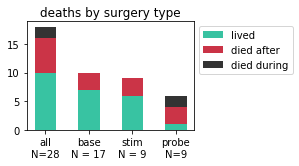

In [7]:
''' proportion of deaths overall and by surgery type'''
# data params
counts = []
for i in np.asarray([2, 1, 0]):
    counts.append(np.asarray([total[i], base_implants[i], stim_implants[i], probe_implants[i]]))
counts[0] = counts[0] - np.asarray([total_deaths, base_deaths, stim_deaths, probe_deaths])
    
# fig params
f, ax = plt.subplots(1, 1, figsize=(3, 2))
bottoms = np.zeros(4)
width = 0.5
category = ['lived', 'died after', 'died during']
conditions = ['all\nN=28', 'base\nN = 17', 'stim\nN = 9', 'probe\nN=9']
colors = ['xkcd:green blue', 'xkcd:scarlet', 'k']

for i, ct in enumerate(counts):
    ax.bar(conditions, ct, width=width, 
           label=category[i], bottom=bottoms, 
           color=colors[i], alpha=0.8)
    bottoms += ct
    
ax.set_title('deaths by surgery type', fontsize=12, pad=5)
ax.legend(bbox_to_anchor=(1, 1, 0, 0))
plt.show()
f.savefig(f'{save_dir}surgery_type_recent.png', dpi=600, bbox_inches='tight')

In [200]:
''' probe implants - deaths vs. survivals '''
total = 0
total_survived = 0

# type of surgery
probe_implants = np.zeros(2)

# duration of surgery
t_surgery_died = np.asarray([])
t_surgery_survived = np.asarray([])

# weight added
w_added_died = np.asarray([])
w_added_survived = np.asarray([])

# volume of saline given
saline_died = np.asarray([])
saline_survived = np.asarray([])

# days since capture/brought to the satellite
d_captivity_died = np.asarray([])
d_captivity_survived = np.asarray([])
d_upstairs_died = np.asarray([])
d_upstairs_survived = np.asarray([])

for i, s in enumerate(surgery_ids):
    surgery = surgeries[s]
    if 'probe' in surgery['procedure']:
        probe_implants[1] += 1
        total += 1
    
        if surgery["survived surgery?"]:
            lived = surgery["survived post-surgery?"]
            total_survived += int(lived)    
        else:
            lived = False

        # compute durations, weight change, etc.
        t_surgery = int((surgery['end time'] - surgery['start time']).seconds / 60)
        w_added = surgery['end weight'] - surgery['start weight']
        d_captivity = (surgery['date'] - surgery['date caught']).days
        d_upstairs = (surgery['date'] - surgery['date upstairs']).days

        if lived:
            t_surgery_survived = np.append(t_surgery_survived, t_surgery)
            w_added_survived = np.append(w_added_survived, w_added)
            d_captivity_survived = np.append(d_captivity_survived, d_captivity)
            d_upstairs_survived = np.append(d_upstairs_survived, d_upstairs)
            saline_survived = np.append(saline_survived, surgery['vol saline (mL)'])
        else:
            t_surgery_died = np.append(t_surgery_died, t_surgery)
            w_added_died = np.append(w_added_died, w_added)
            d_captivity_died = np.append(d_captivity_died, d_captivity)
            d_upstairs_died = np.append(d_upstairs_died, d_upstairs)
            saline_died = np.append(saline_died, surgery['vol saline (mL)'])
            probe_implants[0] += 1

In [201]:
# organize all the data
probe_implants = probe_implants.astype(int)

died_factors = [t_surgery_died, w_added_died, saline_died, d_captivity_died, d_upstairs_died]
survived_factors = [t_surgery_survived, w_added_survived, saline_survived, d_captivity_survived, d_upstairs_survived]

In [202]:
print(f"{total_survived} out of {total} probe implant surgeries survived")

4 out of 9 probe implant surgeries survived


C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\core\_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
C:\Users\ilow1\Anaconda3\lib\site-packages\numpy\linalg\linalg.py:2159: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


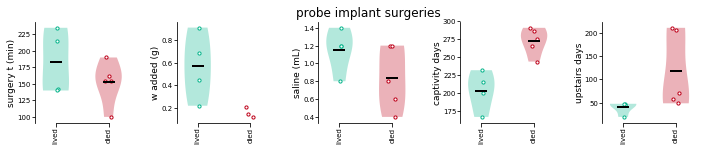

In [203]:
''' probe implants - plot some factors '''
# fig params 
f, ax = plt.subplots(1, len(survived_factors), figsize=(len(survived_factors)*2, 2))
f.tight_layout()
DOT_LW = 1
DOT_SIZE = 10
AVG_LW = 2

lived_color = 'xkcd:green blue'
died_color = 'xkcd:scarlet'
labels = ['surgery t (min)', 'w added (g)', 'saline (mL)', 'captivity days', 'upstairs days']

n_survived = t_surgery_survived.shape[0]
JIT_LIVED = np.random.randn(n_survived) * 0.06 # jitter points
n_died = t_surgery_died.shape[0]
JIT_DIED = np.random.randn(n_died) * 0.06 # jitter points

for i, (died, lived) in enumerate(zip(died_factors, survived_factors)):
    V = ax[i].violinplot([lived, died], showextrema=False)
    for j, v in enumerate(V['bodies']):
        v.set_facecolor(colors[j])
    ax[i].scatter(np.full(n_survived, 1) + JIT_LIVED,
                  lived,
                  facecolors='w', edgecolors=lived_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].scatter(np.full(n_died, 2) + JIT_DIED,
                  died,
                  facecolors='w', edgecolors=died_color,
                  s=DOT_SIZE, lw=DOT_LW, alpha=1
                 )
    ax[i].plot(np.asarray([1, 2]),
               np.asarray([np.mean(lived), np.mean(died)]),
               '_k', ms=12, mew=2
              )
    
for i in range(len(survived_factors)):
    # ticks and lims
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
#     ax[i].spines['left'].set_bounds(0, 1)
    ax[i].spines['bottom'].set_bounds(1, 2)
    ax[i].set_xlim([0.6, 2.5])
    ax[i].set_xticks([1, 2])

    # labels
    ax[i].set_ylabel(labels[i], fontsize=9, labelpad=1)
    ax[i].set_xticklabels(['lived', 'died'], rotation=90)
    ax[i].tick_params(which='major', labelsize=7, pad=0.5)
    
    if i == 2:
        ax[i].set_title('probe implant surgeries', fontsize=12, pad=5)

f.savefig(f'{save_dir}probe_implants.png', dpi=600, bbox_inches='tight')